In [30]:
import os 
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve

roc_aucs = {}
roc_curves = {}

def use_hgcn(df):
    df_copy = df.copy()
    for mutation in df['Mutation']:
        aa_original = mutation[0]
        aa_mutated = mutation[-1]
        aa_index = mutation[1:-1]
        aa_index_hugo = int(aa_index) + 20
        mutation_hugo = f"{aa_original}{aa_index_hugo}{aa_mutated}"
        #print(f"Processing mutation: {mutation}, HUGO mutation: {mutation_hugo}")
        df_copy.loc[df['Mutation'] == mutation, 'Mutation'] = mutation_hugo
    return df_copy

map_resiname = {
    'A': 'Ala', 'C': 'Cys', 'D': 'Asp', 'E': 'Glu', 'F': 'Phe',
    'M': 'Met', 'N': 'Asn', 'P': 'Pro', 'Q': 'Gln', 'R': 'Arg',
    'G': 'Gly', 'H': 'His', 'I': 'Ile', 'K': 'Lys', 'L': 'Leu',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val'
}

map_resiname_inv = {v: k for k, v in map_resiname.items()}


def three2one(mutation):
    """
    Convert a mutation from three-letter amino acid code to one-letter code.
    Example: 'p.Ala123Gly' -> 'A123G'
    """
    mutation = mutation.split(".")[1]  # Extract the mutation part after 'p.'
    if len(mutation) < 4:
        return mutation  # Return as is if the mutation is too short
    aa_original = mutation[:3]
    position = mutation[3:-3]
    aa_mutated = mutation[-3:]
    
    # Convert three-letter code to one-letter code
    aa_original_one = map_resiname_inv.get(aa_original, aa_original)
    aa_mutated_one = map_resiname_inv.get(aa_mutated, aa_mutated)
    
    return f"{aa_original_one}{position}{aa_mutated_one}"

cwd = os.getcwd()
sep = os.sep

parent_dir = os.path.dirname(cwd)
results_path = parent_dir + sep + "results"

df_consequences = pd.read_csv(results_path + sep + "mutations_consequences.csv")
df_consequences.columns = ["Mutation", "Consequence"]
df_consequences['Consequence'] = df_consequences['Consequence'].replace({'Not found': 'Unknown', 'Variant of uncertain significance': 'Unknown'})
df_consequences['Consequence'] = df_consequences['Consequence'].replace({'Likely benign': 'Benign'})
df_consequences['Consequence'] = df_consequences['Consequence'].replace({'Likely pathogenic': 'Pathogenic'})
df_consequences = use_hgcn(df_consequences)
df_consequences_unknown = df_consequences[df_consequences['Consequence'] == 'Unknown']
df_consequences = df_consequences[df_consequences['Consequence'] != 'Unknown']

esnpgo_df = pd.read_csv(cwd + sep + "esnpgo_predictions.tsv", sep="\t")
esnpgo_df = esnpgo_df.rename(columns={'Variation': 'Mutation', 'Prediction': 'Pred_class'})

vesm_df = pd.read_csv(cwd + sep + "vesm_predictions.csv")

alphamissense_output = cwd + sep + "alphamissense_P02766.tsv"
alphamissense_df = pd.read_csv(alphamissense_output, sep = "\t")
alphamissense_df = alphamissense_df.filter(['protein variant', 'pathogenicity score', 'pathogenicity class'])
alphamissense_df = alphamissense_df.replace({'pathogenicity class': {'likely_benign': 'Benign', 'likely_pathogenic': 'Pathogenic'}})
alphamissense_df = alphamissense_df.rename(columns={'protein variant': 'Mutation', 'pathogenicity score': 'Pathogenicity_probability', 'pathogenicity class': 'Pred_class'})
alphamissense_df['Mutation'] = [three2one(mutation) for mutation in alphamissense_df['Mutation']]

esm2_umap_output = cwd + sep + "esm2_umap_predictions.csv"
esm2_umap_df = pd.read_csv(esm2_umap_output)
esm2_umap_df = esm2_umap_df.rename(columns={"Distance_wt": 'Pathogenicity_probability'})
esm2_umap_df = use_hgcn(esm2_umap_df)

def get_roc_curve(df, df_pred, label):

    df = df.copy()
    df_pred = df_pred.copy()
    
    thresholds = {
        "esm2+umap": 0.35,
        "vesm++": 0.2
    }

    df_pred = df_pred[df_pred['Mutation'].isin(df['Mutation'])]

    if label == "esm2_umap":
        threshold = thresholds[label]
        print(f"Using threshold {threshold} for {label}")
        df_pred['Pred_class'] = predict_threshold(df_pred, threshold=threshold)

    y_pred = df_pred['Pred_class'].tolist()    
    y_probs = df_pred['Pathogenicity_probability'].tolist()
    y_true = df['Consequence'].tolist()

    if 1 in df_pred['Pred_class'].values:
        y_pred = df_pred['Pred_class'].tolist()
    else:
        y_pred = [1 if pred == 'Pathogenic' else 0 for pred in y_pred]
        
    if 1 in y_true:
        y_true = df['Consequence'].tolist()
    else:
        y_true = [1 if true == 'Pathogenic' else 0 for true in y_true]

    rocauc = roc_auc_score(y_true, y_pred)
    if label == "vesm++":
        fpr, tpr, _ = roc_curve(y_true, y_pred, pos_label=1)
    else:
        fpr, tpr, _ = roc_curve(y_true, y_probs, pos_label=1)
    
    print(len(fpr), len(tpr), len(y_true))
    roc_aucs[label] = round(rocauc, 4)
    roc_curves[label] = (fpr, tpr)

def predict_threshold(df, threshold=0.5):

    y_preds = []
    for i, row in df.iterrows():
        y_pred = 1 if row['Pathogenicity_probability'] >= threshold else 0
        y_preds.append(y_pred)
    return np.array(y_preds)

def plot_roc_curves(roc_curves, roc_aucs):
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(14, 10))
    for label, (fpr, tpr) in roc_curves.items():
        plt.plot(fpr, tpr, label=f"$\\bf {label} (AUC = {roc_aucs[label]})$")
        plt.scatter(fpr, tpr, s=10, alpha=0.5)  # Add scatter points for better visibility

    plt.plot([0, 1], [0, 1], 'k--', label='$\\bf Random$')
    plt.xlabel('False Positive Rate', fontsize=28, weight='bold')
    plt.ylabel('True Positive Rate', fontsize=28, weight='bold')
    plt.title('ROC Curves on TTR variant classification', fontsize=36, weight='bold')
    plt.legend(loc='lower right', fontsize=22)
    plt.grid()
    return fig 

In [31]:
get_roc_curve(df_consequences, esnpgo_df, "esnpgo")
get_roc_curve(df_consequences, vesm_df, "vesm++")
get_roc_curve(df_consequences, alphamissense_df, "alphamissense")
get_roc_curve(df_consequences, esm2_umap_df, "esm2+umap")
roc_aucs

15 15 98
3 3 98
9 9 98
6 6 98


{'esnpgo': 0.4792,
 'vesm++': 0.9219,
 'alphamissense': 0.6771,
 'esm2+umap': 0.9948}

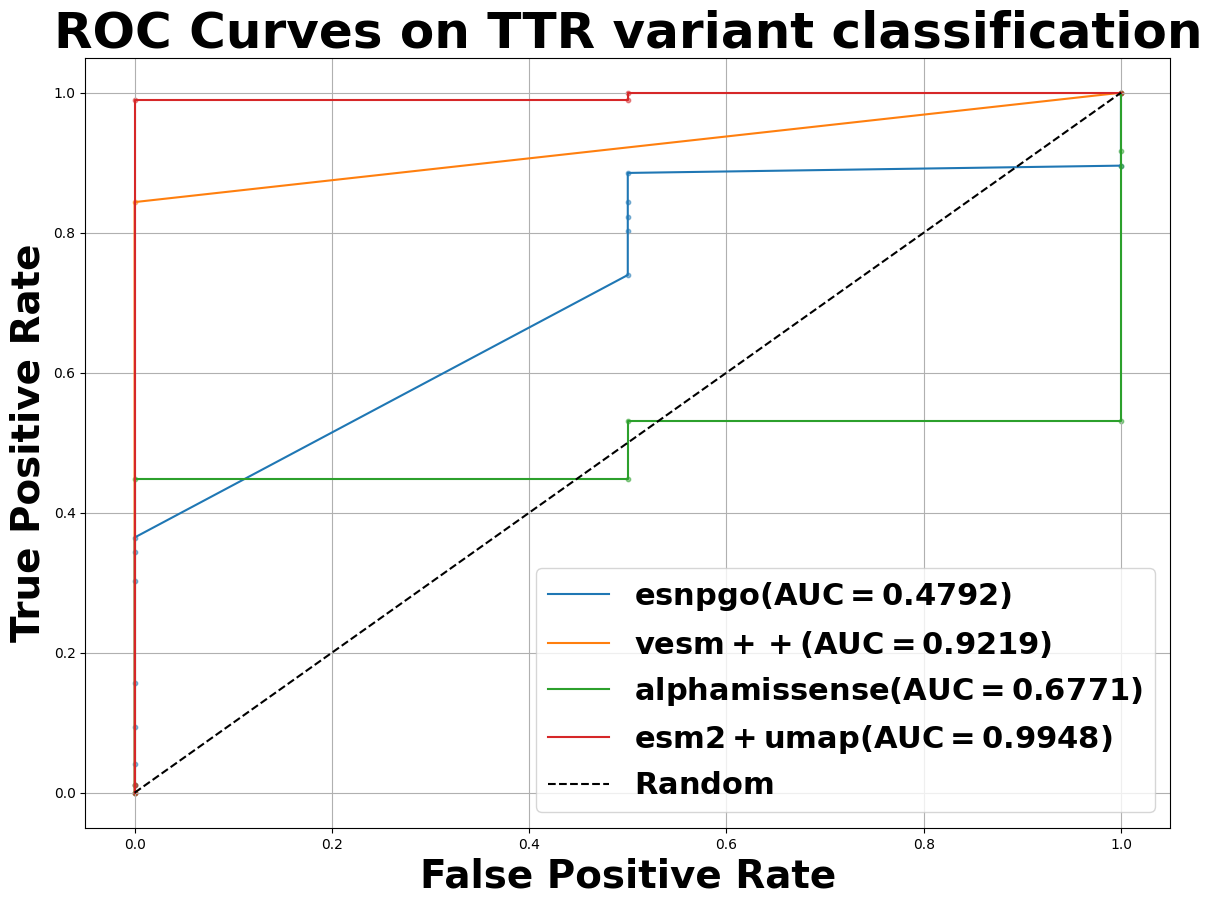

In [33]:
fig = plot_roc_curves(roc_curves, roc_aucs)
fig.savefig(cwd + sep + "roc_curves.png", dpi=600, bbox_inches='tight')